# Improving Neural Network Training (Keras)

This notebook explores techniques that improve training stability and generalization in neural networks.

We implement:

- Batch Normalization
- Dropout Regularization
- Improved training dynamics

---

## Objective

Understand how modern deep learning models achieve stable and efficient training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

I0000 00:00:1775476177.540839   10396 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775476177.586799   10396 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775476179.197892   10396 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


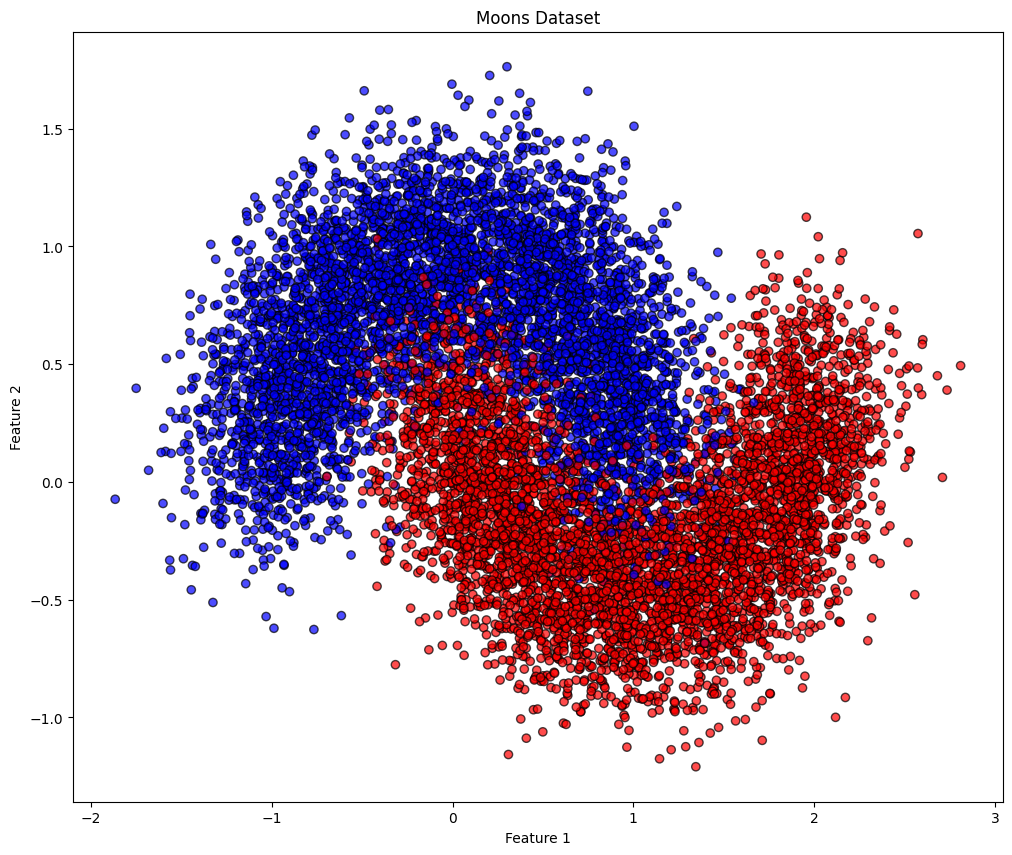

In [2]:
X, y = make_moons(n_samples=10000, noise=0.25, random_state=42)

plt.figure(figsize=(12, 10))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap = "bwr", edgecolor="k", alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
baseline_model = keras.Sequential([
    keras.Input(shape=(2,),),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_baseline = baseline_model.fit(X_train, y_train, epochs=50, validation_split=0.2, verbose=1)

Epoch 1/50


E0000 00:00:1775476179.883604   10396 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8555 - loss: 0.3562 - val_accuracy: 0.8727 - val_loss: 0.2962
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8940 - loss: 0.2507 - val_accuracy: 0.9113 - val_loss: 0.2201
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9325 - loss: 0.1816 - val_accuracy: 0.9373 - val_loss: 0.1705
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9423 - loss: 0.1521 - val_accuracy: 0.9387 - val_loss: 0.1521
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9425 - loss: 0.1439 - val_accuracy: 0.9373 - val_loss: 0.1467
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9450 - loss: 0.1405 - val_accuracy: 0.9373 - val_loss: 0.1480
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9445 - loss: 0.1395 - val_accuracy: 0.9367 - val_loss: 0.1499
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9433 - loss: 0.1381 - val_accuracy: 0.9360 - val_

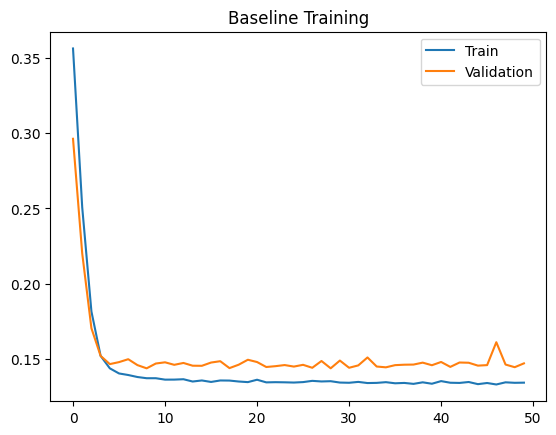

In [6]:
plt.plot(history_baseline.history["loss"], label="Train")
plt.plot(history_baseline.history["val_loss"], label="Validation")

plt.title("Baseline Training")
plt.legend()
plt.show()

In [7]:
improved_model = keras.Sequential([
    keras.Input(shape=(2,)),

    keras.layers.Dense(50, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(50, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(1, activation="sigmoid")
])

In [8]:
improved_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_improved = improved_model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8715 - loss: 0.3130 - val_accuracy: 0.9193 - val_loss: 0.3245
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9205 - loss: 0.2172 - val_accuracy: 0.9333 - val_loss: 0.1872
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9228 - loss: 0.2026 - val_accuracy: 0.9373 - val_loss: 0.1552
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9282 - loss: 0.1885 - val_accuracy: 0.9373 - val_loss: 0.1516
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9260 - loss: 0.1873 - val_accuracy: 0.9387 - val_loss: 0.1493
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9333 - loss: 0.1871 - val_accuracy: 0.9360 - val_loss: 0.1502
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9357 - loss: 0.1761 - val_accuracy: 0.9353 - val_loss: 0.1501
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9308 - loss: 0.1793 - val_accuracy: 0.

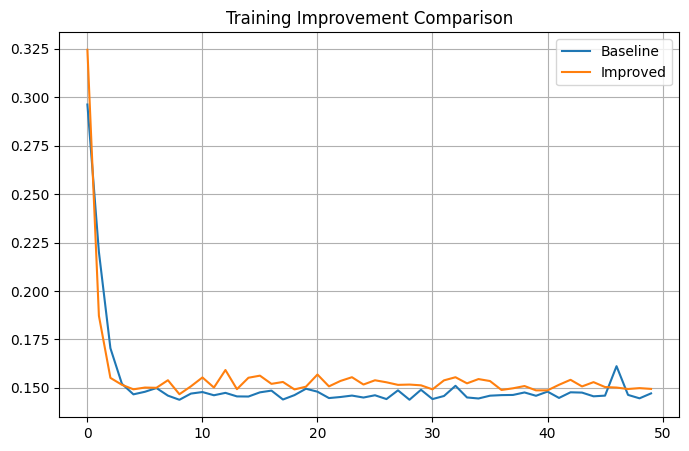

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history["val_loss"], label="Baseline")
plt.plot(history_improved.history["val_loss"], label="Improved")

plt.title("Training Improvement Comparison")
plt.legend()
plt.grid(True)

plt.show()

## Interpretation

### Baseline Model
- May overfit
- Less stable training

---

### Improved Model

- Batch Normalization stabilizes training
- Dropout reduces overfitting
- Better generalization

---

## Key Insight

Modern deep learning relies heavily on:

- Normalization
- Regularization
- Proper optimization

These techniques make deep networks trainable.